In [3]:
import matplotlib.pyplot as plt
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.layers import Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
import random as rn
import cv2
import numpy as np
from tqdm import tqdm
import tensorflow as tf

2023-12-21 13:36:53.174727: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
train_images: list = []
train_labels: list = []
ScaleTo = 224
seed = 7
j = 1
path = "../data/greens/*/*.jpeg"
files = glob(path)
number = len(files)
print(files)
for image in tqdm(files):
    try:
        train_images.append(cv2.resize(cv2.imread(image), (ScaleTo, ScaleTo)))
        train_labels.append(image.split('/')[-2])
    except Exception:
        continue

np_train_images = np.asarray(train_images)

# pd_train_labels = pd.DataFrame(train_labels)



['../data/greens/taze_sogan/IMG_7820.jpeg', '../data/greens/taze_sogan/IMG_8540.jpeg', '../data/greens/taze_sogan/IMG_8281.jpeg', '../data/greens/taze_sogan/IMG_6323.jpeg', '../data/greens/taze_sogan/IMG_8297.jpeg', '../data/greens/taze_sogan/IMG_8278.jpeg', '../data/greens/taze_sogan/IMG_2049.jpeg', '../data/greens/taze_sogan/IMG_8413.jpeg', '../data/greens/taze_sogan/IMG_1976.jpeg', '../data/greens/taze_sogan/IMG_8741.jpeg', '../data/greens/taze_sogan/IMG_7772.jpeg', '../data/greens/taze_sogan/IMG_8429.jpeg', '../data/greens/taze_sogan/IMG_6319.jpeg', '../data/greens/taze_sogan/IMG_7764.jpeg', '../data/greens/taze_sogan/IMG_2136.jpeg', '../data/greens/taze_sogan/IMG_8409.jpeg', '../data/greens/taze_sogan/IMG_6155.jpeg', '../data/greens/taze_sogan/IMG_8262.jpeg', '../data/greens/taze_sogan/IMG_8274.jpeg', '../data/greens/taze_sogan/IMG_8736.jpeg', '../data/greens/taze_sogan/IMG_2291.jpeg', '../data/greens/taze_sogan/IMG_7791.jpeg', '../data/greens/taze_sogan/IMG_8258.jpeg', '../data/g

100%|██████████| 2822/2822 [03:59<00:00, 11.78it/s]


In [5]:
print(len(set(train_labels)))

10


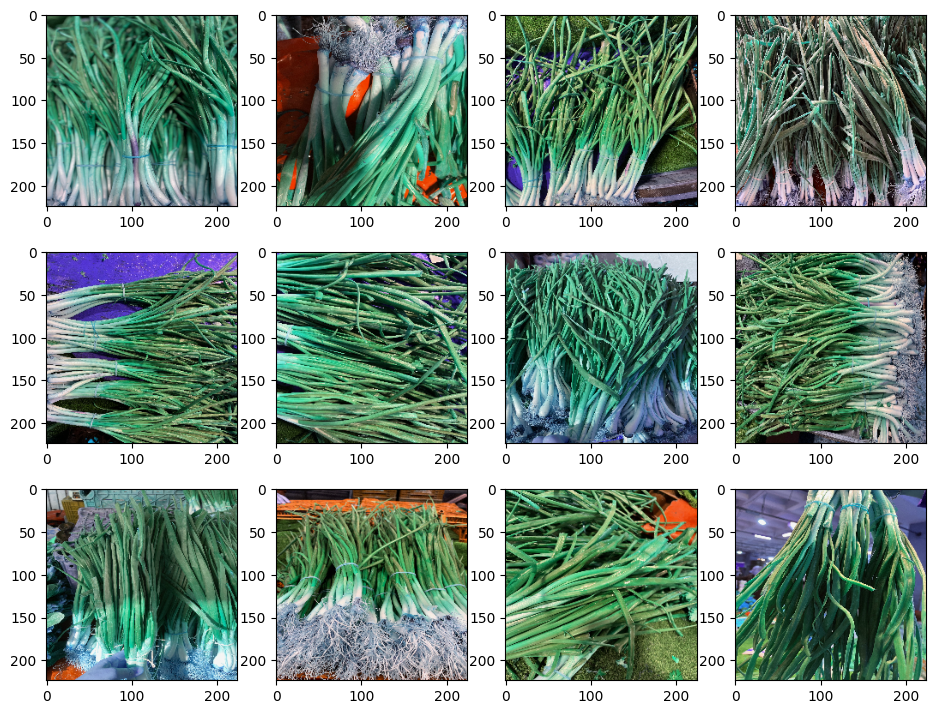

In [6]:
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(np_train_images[i])
    plt.subplots_adjust(bottom=0.1, right=1.5, top=1.5)

In [7]:
np_train_images = np_train_images / 255

In [8]:
le = LabelEncoder()
Y = le.fit_transform(train_labels)
Y = to_categorical(Y)
print(len(train_labels))
print(Y.shape)

2822
(2822, 10)


In [9]:
print(type(train_images))
print(len(train_images))
print(train_images[1].shape)

<class 'list'>
2822
(224, 224, 3)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(np_train_images, Y, test_size=0.20, random_state=42)

In [11]:
np.shape(X_train), np.shape(y_train), np.shape(X_test), np.shape(y_test)

((2257, 224, 224, 3), (2257, 10), (565, 224, 224, 3), (565, 10))

In [12]:
np.random.seed(42)
rn.seed(42)
tf.random.set_seed(42)

In [13]:
datagen = ImageDataGenerator(
    rotation_range=180,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True
)
datagen.fit(X_train)

In [14]:
model = Sequential()
model.add(Conv2D(60, (5, 5), input_shape=(ScaleTo, ScaleTo, 3), activation="relu"))
model.add(Conv2D(60, (5, 5), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(30, (3, 3), activation="relu"))
model.add(Conv2D(30, (3, 3), activation="relu"))
model.add(MaxPooling2D(pool_size=(2, 2)))
#model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(500, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation="softmax"))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 220, 220, 60)      4560      
                                                                 
 conv2d_1 (Conv2D)           (None, 216, 216, 60)      90060     
                                                                 
 max_pooling2d (MaxPooling2  (None, 108, 108, 60)      0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 106, 106, 30)      16230     
                                                                 
 conv2d_3 (Conv2D)           (None, 104, 104, 30)      8130      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 52, 52, 30)        0         
 g2D)                                                   

In [15]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
batchSize = 250
ep = 10
model.fit(X_train, y_train, batch_size=batchSize, epochs=ep, validation_split=.15)

Epoch 1/10
8/8 [==============================] - 579s 72s/step - loss: 3.2222 - accuracy: 0.1298 - val_loss: 2.2266 - val_accuracy: 0.1563
Epoch 2/10
8/8 [==============================] - 596s 74s/step - loss: 2.2456 - accuracy: 0.1512 - val_loss: 2.2394 - val_accuracy: 0.1563
Epoch 3/10
8/8 [==============================] - 516s 65s/step - loss: 2.1960 - accuracy: 0.1653 - val_loss: 2.0733 - val_accuracy: 0.1740
Epoch 4/10
8/8 [==============================] - 465s 59s/step - loss: 2.1630 - accuracy: 0.2164 - val_loss: 2.0979 - val_accuracy: 0.1711
Epoch 5/10
8/8 [==============================] - 477s 60s/step - loss: 2.0216 - accuracy: 0.2596 - val_loss: 1.9274 - val_accuracy: 0.2920
Epoch 6/10
8/8 [==============================] - 643s 83s/step - loss: 1.8043 - accuracy: 0.3603 - val_loss: 1.8242 - val_accuracy: 0.2891
Epoch 7/10
8/8 [==============================] - 411s 50s/step - loss: 1.6299 - accuracy: 0.4197 - val_loss: 1.7806 - val_accuracy: 0.3923
Epoch 8/10
8/8 [====

In [17]:
history = _

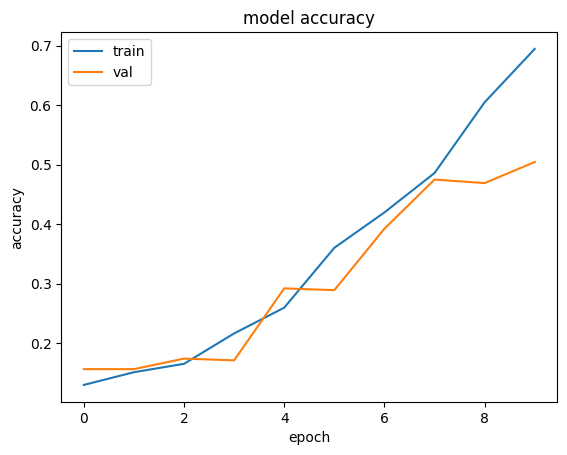

In [18]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

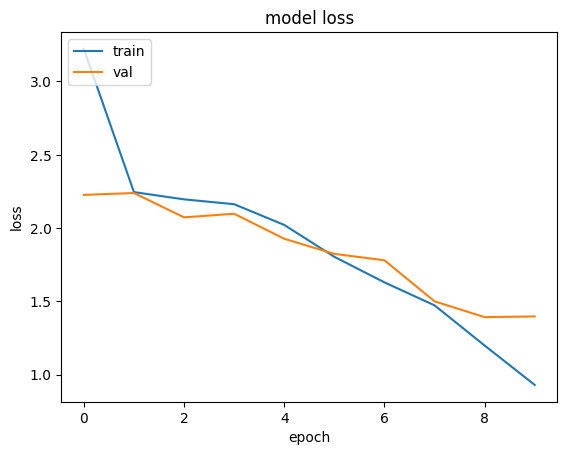

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [21]:
model.save("../model/greens.keras")

In [22]:
model.evaluate(X_test, y_test)

18/18 [==============================] - 17s 966ms/step - loss: 1.2714 - accuracy: 0.5522


[1.2714314460754395, 0.5522124171257019]

In [77]:
pred = model.predict(X_test)
print("Predicted Probabilities -\n", pred[:4])
pred_digits = np.argmax(pred, axis=1)
print("\nPredicted Class [Highest Prob] -", pred_digits[:4])

3/3 [==============================] - 1s 160ms/step
Predicted Probabilities -
 [[9.73783054e-10 1.27811650e-15 6.79672891e-32 3.21787441e-09
  6.27187727e-20 1.12299189e-12 1.79226004e-06 6.92838013e-01
  1.48174943e-13 5.00304748e-20 1.85468059e-32 2.49713897e-37
  2.45948003e-33 3.03701149e-22 3.07160139e-01 1.13984496e-17]
 [5.35540760e-01 1.54846627e-03 2.07828563e-08 8.37122090e-03
  7.32185872e-05 1.15967030e-02 1.16815837e-03 7.88673060e-04
  1.84293793e-04 3.13102901e-02 4.35494196e-10 4.41905290e-10
  3.26485399e-08 5.65009145e-07 3.64931487e-02 3.72924417e-01]
 [2.38395437e-08 1.86948319e-18 1.26230248e-36 8.79978201e-10
  5.05616532e-24 5.84777994e-14 5.87783179e-05 3.94524932e-01
  3.47612316e-16 5.42813463e-25 3.64550621e-37 0.00000000e+00
  0.00000000e+00 2.04167470e-25 6.05416358e-01 3.58817832e-23]
 [6.20371593e-12 3.80909294e-17 4.10619193e-37 2.70043623e-11
  8.21966715e-24 9.52549430e-16 2.53305416e-07 6.19345810e-03
  1.70264161e-17 3.38905295e-25 2.71684754e-35 0.